<div align="center">
  <h1><b> Quantum Computing </b></h1>
  <h2> Quantum Gates </h2>
  <h3> Multi-Qubit Gates </h3>
</div>

<br>
<b>Author:</b> <a target="_blank" href="https://github.com/camponogaraviera">Lucas Camponogara Viera</a>

# Table of Contents

- [$C_n^{j}(U_{2^m})$ Gate](#cnj-u2m-gate)
- [Toffoli Gate](#toffoli-gate)


# &nbsp; <img valign="middle" height="45px" src="https://img.icons8.com/python" width="45" hspace="0px" vspace="0px"> Importing modules

In [3]:
%run implementations.ipynb

{'commit_hash': '786b192',
 'commit_source': 'installation',
 'default_encoding': 'utf-8',
 'ipython_path': '/home/ibmq/anaconda3/envs/qc-qiskit/lib/python3.11/site-packages/IPython',
 'ipython_version': '9.7.0',
 'os_name': 'posix',
 'platform': 'Linux-6.14.0-37-generic-x86_64-with-glibc2.39',
 'sys_executable': '/home/ibmq/anaconda3/envs/qc-qiskit/bin/python',
 'sys_platform': 'linux',
 'sys_version': '3.11.0 | packaged by conda-forge | (main, Jan 14 2023, '
                '12:27:40) [GCC 11.3.0]'}


# $C_n^{j}(U_{2^m})$ Gate

Let $U_{2^m}$ be a $2^m$ x $2^m$ unitary matrix and $I_{2^m}$ be a $2^m$ x $2^m$ identity matrix, then a generic multicontrolled gate with $n$ control qubits and $m$ target qubits can be written as:

\begin{equation}
C_n^{j}(U_{2^m}) = \sum_{i=0, i\neq j}^{2^n-1} \mathbb{I}_{2^m} \otimes |i\rangle\langle i|+ U_{2^m} \otimes |j\rangle\langle j|.
\end{equation}

## Particular cases

CNOT Gate:

\begin{align}
CX \equiv C_1(X_{2^1}) = \sum_{i=0, i\neq j}^{2^1-1} \mathbb{I}_{2^1} \otimes |i\rangle\langle i| + X_{2^1} \otimes |j\rangle\langle j| = \mathbb{I}_2 \otimes |0\rangle\langle 0\rangle + X \otimes |1 \rangle \langle 1|.
\end{align}

In a similar fashion:

$CRY  = CU3(\theta, 0,0) \equiv C_1(RY_{2^1}) = \mathbb{I}_2 \otimes |0\rangle\langle 0\rangle + RY(\theta) \otimes |1 \rangle \langle 1|$.

In a similar fashion:

$CCRY \equiv C_1(CRY)_{2^2} = \mathbb{I}_2 \otimes \mathbb{I}_2 \otimes |0\rangle\langle 0\rangle + CRY \otimes |1 \rangle \langle 1|$.

$CCCX \equiv C_1(CCX)_{2^3} = \mathbb{I}_2 \otimes \mathbb{I}_2 \otimes \mathbb{I}_2 \otimes |0\rangle\langle 0\rangle + CCX \otimes |1 \rangle \langle 1|$.

$CCCRY \equiv C_1(CCRY)_{2^3} = \mathbb{I}_2 \otimes \mathbb{I}_2 \otimes \mathbb{I}_2 \otimes |0\rangle\langle 0\rangle + CCRY \otimes |1 \rangle \langle 1|$.

# Toffoli Gate

$$CCX \equiv C_1(CX)_{2^2} = \sum_{i=0, i\neq j}^{2^1-1} \mathbb{I}_{2^2} \otimes |i\rangle\langle i|+ (CX)_{2^2} \otimes |j\rangle\langle j| = \mathbb{I}_2 \otimes \mathbb{I}_2 \otimes |0\rangle\langle 0\rangle + CX \otimes |1 \rangle \langle 1|.$$

The action of the Toffoli gate is to negate the target bit if the first two control bits are 1. 

The Toffoli gate is not a native gate of NISQ quantum hardware, and it has to be decomposed into elementary single-qubit and two-qubit native gates.

Decomposition in terms of the Clifford+T finite gate set {H, S, CNOT, T} (see Nielsen and Chuang Fig. 4.9):

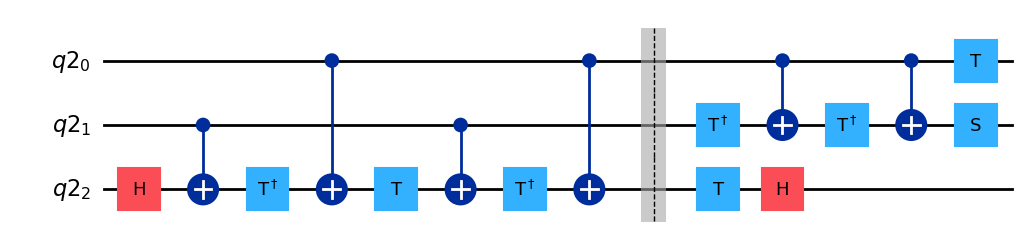

In [6]:
qr = QuantumRegister(3)                
qc = QuantumCircuit(qr)
qc.h(2)      
qc.cx(1,2)   
qc.tdg(2)   
qc.cx(0,2)
qc.t(2)   
qc.cx(1,2)
qc.tdg(2)   
qc.cx(0,2)   
qc.barrier()
qc.tdg(1)   
qc.t(2)   
qc.cx(0,1)   
qc.h(2)
qc.tdg(1)
qc.cx(0,1)  
qc.t(0)  
qc.s(1)  

qc.draw(output='mpl')

# &nbsp; <a href="#"><img valign="middle" height="45px" src="https://img.icons8.com/book" width="45" hspace="0px" vspace="0px"></a> References<a name="ref" />

[1] Nielsen MA, Chuang IL. 2010. Quantum Computation and Quantum Information. New York: [Cambridge Univ. Press.](https://doi.org/10.1017/CBO9780511976667) 10th Anniv. Ed. 